**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 1: Alien Pet Health, Data Preparation*

# Identification

Name: Jamie Bly<br/>
Student Number: 300231604

## 1. Data

The dataset for Assignment 1 can be found here:

- [github.com/turcotte/csi4106-f25/tree/main/assignments-data/a1](https://github.com/turcotte/csi4106-f25/tree/main/assignments-data/a1)

In your notebook, you can access and read the data directly from this GitHub repository.

- [alien_pet_health.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a1/alien_pet_health.csv)

## 2. Tasks

1. **Load the dataset**

	- Read the CSV file from the provided GitHub URL.
	- Show the shape of the data, as well as the first five rows.

In [1]:
# Code cell
%pip install pandas 
import pandas as pd
import numpy as np

data = pd.read_csv("https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a1/alien_pet_health.csv")
print(data.shape)
print(data.head())

Note: you may need to restart the kernel to use updated packages.
(5000, 14)
   record_id  thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0  P22042111               52.6                   97.0               3.6   
1  P21571318               41.8                  105.0               3.4   
2  P81737259               56.2                  126.0               5.5   
3  P54935007               57.7                  106.0              -4.1   
4  P63102956               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  \
0                -3.5           c2             2.0           0.0   
1                10.5           c1             2.0           0.0   
2                 9.6           c2             5.0           0.0   
3                -4.0           c1             4.0           0.0   
4                 0.3           c4             5.0           1.0   

   health_outcome station_code  ingest_marker calibration

2. **Missing values**

	- Examine the dataset to identify and assess missing values in various attributes. Missing values may be represented by symbols such as ‘?’, empty strings, or other placeholders.
	- List the attribute or attributes with missing values.
	- Describe the methodology used for this investigation, and provide the corresponding code, if applicable.
	- Convert missing tokens (e.g., empty strings, `n/a`, `?`) to `NaN`.
	- Coerce numeric-like columns to numeric (errors→`NaN`).

	Following this step, each attribute will be populated with either specific values or `NaN`.

In [2]:
# Code cell
#Seperate table for cleaned up data
cleanData = data
# Examination of Data Results for missing values
#First, we look at general cases, as follows, setting all values to the numpy NaN value.
cleanData = cleanData.replace('', np.nan)
cleanData = cleanData.fillna(np.nan)
cleanData = cleanData.replace('?', np.nan)
cleanData = cleanData.replace('N/a', np.nan)




3. **Categorical attributes**

	- Analyze the dataset to detect potential issues with categorical attributes. For example, you may encounter instances where the same category is inconsistently represented using both lowercase and uppercase letters, or where extraneous spaces are included.
	- Describe the methodology used for this investigation, and provide the corresponding code, if applicable.
	- Normalize the values of categorical attributes.

In [3]:
# Code cell
# Makes record_id column have all P be uppercase
cleanData ['record_id']= cleanData['record_id'].str.upper()


# Clean up double values columns. These are rounded to their the average entry to ensure uniform data.
# Ensure all value only have 1 decimal point for thermoreg, dual_lobe_signal and stress_variablility.
# All are rounded to 1 decimal point as all are within <0.1^-9 error, which is irrevelant 
cleanData['thermoreg_reading'] =  cleanData['thermoreg_reading'].astype(float).round(1)
cleanData['dual_lobe_signal'] = cleanData['dual_lobe_signal'].astype(float).round(1)
cleanData['stress_variability'] = cleanData['stress_variability'].astype(float).round(1)
# rounds to the nearest integer as most values to the nearest integer
cleanData['enzyme_activity_index'] = cleanData['enzyme_activity_index'].astype(float).round()
cleanData['activity_score'] = cleanData['activity_score'].astype(float).round()

# Cleans up habitat zone columns. Make sure all of C's are lower case
cleanData['habitat_zone'] = cleanData['habitat_zone'].str.upper()

# Cleans up station_code and calibration tag. Ensure that value is in Upper case
cleanData['station_code'] = cleanData['station_code'].str.upper()
cleanData['calibration_tag'] = cleanData['calibration_tag'].str.upper()

# Fasting Flag and health_outcome. Only unique values of NaN, 1.0 /1and 0.0/0 after initial cleanup.
# These columns don't need further clean up.

# Rounding last two to 5th decimal point as it will make data more easily digestable.
cleanData['diagnostic_noise'] = cleanData['diagnostic_noise'].astype(float).round(5)
cleanData['thermoreg_reading_fahrenheit'] = cleanData['thermoreg_reading_fahrenheit'].astype(float).round(5)

4. **Remove non-informative attributes**

	- Eliminate the following types of attributes from the dataset, if applicable:
	  - Unique identifiers (IDs)
	  - Constant and quasi-constant features
	  - High-cardinality quasi-identifiers
	  - Scaled linear duplicates
	- Provide the list of the specific attributes being removed.
	- For each attribute listed, offer a brief justification for its exclusion.

In [4]:
# Code cell
# Attributes being removed
# record_id: Attribute is a unique identifier.
print(cleanData['ingest_marker'].value_counts(normalize=True) * 100)
# ingest_marker: Attribute is a quasi-constant, only having value 1.0 or NaN, and most are 1.0 (~95 as per above).
# thermoreg_reading_fahrenheit: Attribute is a scaled linear dup of thermoreg_reading.
print(cleanData['calibration_tag'].value_counts(normalize=True) * 100)
# calibration_tag: Using the above code, we can find that this attribute is ~93 A, ~5 NaN and ~2 B, which I believe to be quasi constant s
# since >98% of all non-blank values are A. 

cleanData.drop('record_id', axis=1, inplace=True)
cleanData.drop('ingest_marker', axis=1, inplace=True)
cleanData.drop('thermoreg_reading_fahrenheit', axis=1, inplace=True)
cleanData.drop('calibration_tag', axis=1, inplace=True)


print(cleanData.head)



ingest_marker
1.0    100.0
Name: proportion, dtype: float64
calibration_tag
A    97.901364
B     2.098636
Name: proportion, dtype: float64
<bound method NDFrame.head of       thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0                  52.6                   97.0               3.6   
1                  41.8                  105.0               3.4   
2                  56.2                  126.0               5.5   
3                  57.7                  106.0              -4.1   
4                  34.5                   73.0               2.3   
...                 ...                    ...               ...   
4995               58.8                  119.0               5.8   
4996               47.4                   64.0               4.8   
4997               56.4                   88.0               6.6   
4998               50.6                   82.0               4.3   
4999               43.0                   73.0               7.9   

      stress_v

5. **Characterize distributions**

	- For each numerical attribute, provide a detailed characterization of its value distribution. 
		- Evaluate whether the distribution exhibits normality or skewness.
		- Determine if it is unimodal or multimodal.
		- Identify the presence of any outliers.
		- Justify your answers.
	- Create histograms to visually support your findings.

Note: you may need to restart the kernel to use updated packages.
       thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
count        4701.000000            4743.000000       4756.000000   
mean           49.481408             103.436643          2.007717   
std            11.625386              38.814923          2.998535   
min           -79.300000               0.000000         -6.500000   
25%            44.400000              80.000000         -0.400000   
50%            49.900000             101.000000          2.500000   
75%            54.900000             121.000000          4.500000   
max           138.800000             350.000000          8.900000   

       stress_variability  activity_score  fasting_flag  health_outcome  \
count         4709.000000     4771.000000   4764.000000      5000.00000   
mean             0.015778        2.968560      0.403862         0.49980   
std              4.985245        1.287847      0.490722         0.50005   
min         

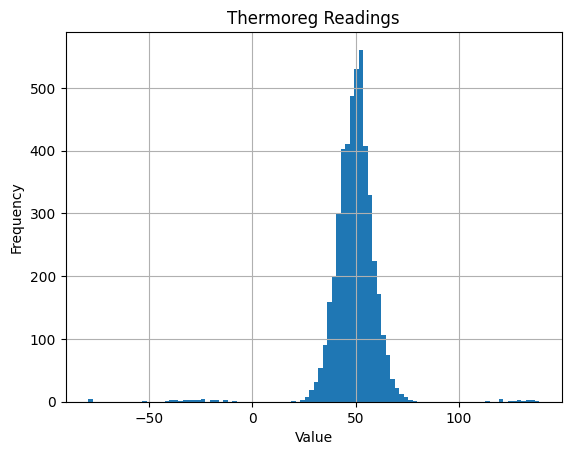

IQR value for column thermoreg_reading is: 10.5
Percentage of Lower Outliers: 1.17 
Percentage of Upper Outliers: 0.872


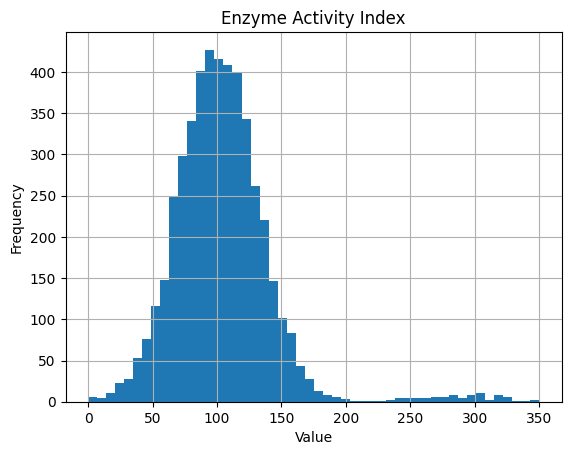

IQR value for column enzyme_activity_index is: 41.0
Percentage of Lower Outliers: 0.358 
Percentage of Upper Outliers: 2.151


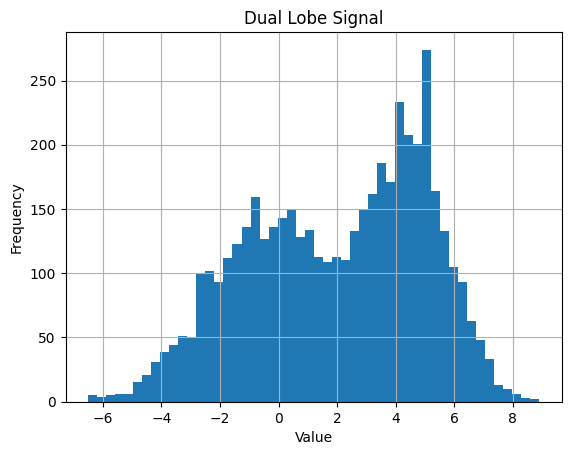

IQR value for column dual_lobe_signal is: 4.9
Percentage of Lower Outliers: 0.0 
Percentage of Upper Outliers: 0.0


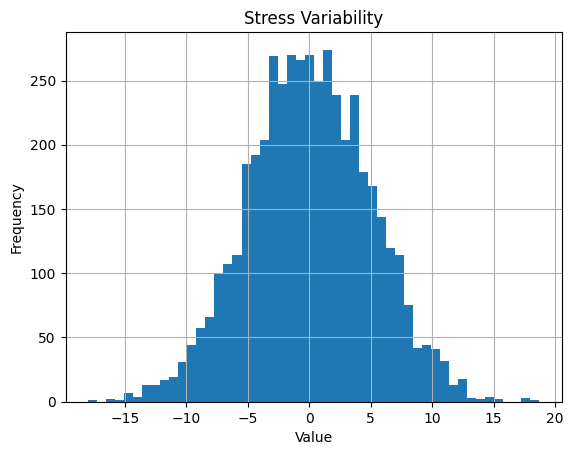

IQR value for column stress_variability is: 6.8
Percentage of Lower Outliers: 0.319 
Percentage of Upper Outliers: 0.212


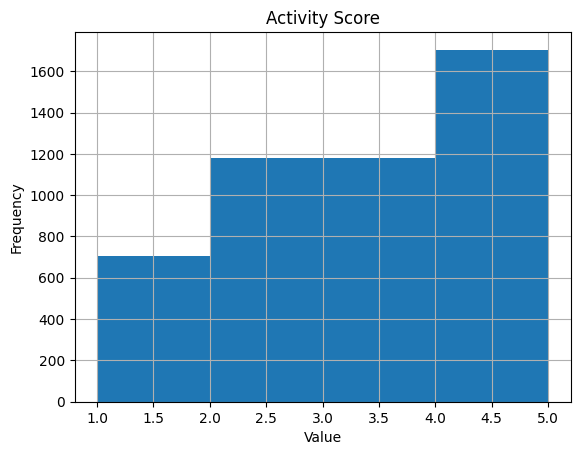

IQR value for column activity_score is: 2.0
Percentage of Lower Outliers: 0.0 
Percentage of Upper Outliers: 0.0


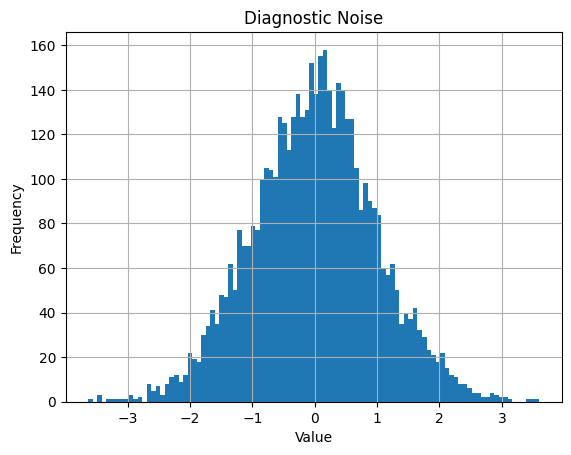

IQR value for column diagnostic_noise is: 1.286695
Percentage of Lower Outliers: 0.528 
Percentage of Upper Outliers: 0.528


In [5]:
# Code cell
%pip install matplotlib
import matplotlib.pyplot as plt
print(cleanData.describe())

def defineOutliers(d, column):
    Q1 = d[column].quantile(0.25)
    Q3 = d[column].quantile(0.75)
    IQR = Q3-Q1

    print("IQR value for column %s is: %s" % (column, IQR))

    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR

    outlier_lower_list = [x for x in d[column] if (x < lower_range)]
    outlier_upper_list = [x for x in d[column] if (x > upper_range)]
    lower_outlier_percent =  ( ( len(outlier_lower_list)/ d[column].count() ) *100).astype(float).round(3)
    upper_outlier_percent =  ( ( len(outlier_upper_list)/ d[column].count() ) *100).astype(float).round(3)
    print("Percentage of Lower Outliers: %s \nPercentage of Upper Outliers: %s" % (lower_outlier_percent, upper_outlier_percent))
    

treg_hist = cleanData['thermoreg_reading'].hist(bins=100)
plt.title("Thermoreg Readings")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
#Distribution is normal since it is symmetric and creates a "Bell" shaped gragh, with most of the data is clustered around the mean
#The graph is unimodal since it has one peak 
defineOutliers(cleanData, "thermoreg_reading")
#Outliers are as defined above using IQR  

enzyme_hist = cleanData['enzyme_activity_index'].hist(bins=50) 
plt.title("Enzyme Activity Index")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
#Distribution is normal since it is symmetric and creates a "Bell" shaped gragh, with most of the data is clustered around the mean
#The graph is unimodal since it has one peak 
defineOutliers(cleanData, "enzyme_activity_index")
#Outliers are defined above using IQR. Most of Outliers are between 250-325.

dls_hist = cleanData['dual_lobe_signal'].hist(bins=50)
plt.title("Dual Lobe Signal")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
defineOutliers(cleanData, "dual_lobe_signal")
#Distribution is not normal since it is not symmetric and data is not quite clustered around the mean
#The graph is multimodal since it has multiple peaks (Peaks: ~-1 to 0 and ~4 to 5) 
#Outliers are defined above using IQR. IQR defintion determines that number of outliers are insignificant. 

stressVar_hist = cleanData['stress_variability'].hist(bins=50)
plt.title("Stress Variability")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
defineOutliers(cleanData, "stress_variability")
#Distribution is normal since it is symmetric and creates a "Bell" shaped gragh, with most of the data is clustered around the mean
#The graph is unimodal since it has one peak 
#Outliers are defined above using IQR. The distributuion is relatively normal compared to rest of data

activityscore_hist = cleanData['activity_score'].hist(bins=4)
plt.title("Activity Score")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
defineOutliers(cleanData, "activity_score")
#Distribution is not normal since the graph is not symmetric. The graph is Linear.
#The graph is unimodal since it has one peak 
#Outliers are defined above using IQR. IQR defintion determines that number of outliers are insignificant. 

dnoise_hist = cleanData['diagnostic_noise'].hist(bins=100)
plt.title("Diagnostic Noise")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()
defineOutliers(cleanData, "diagnostic_noise")
#Distribution is normal since it is symmetric and creates a "Bell" shaped gragh, with most of the data is clustered around the mean
#The graph is unimodal since it has one peak 
#Outliers are defined above using IQR. The distributuion of the outliers is relatively normal compared to rest of data


6. **Class balance**

	- Report target proportions; include a simple bar chart.

Target proportion for thermoreg_reading: 97.958
Target proportion for enzyme_activity_index: 97.491
Target proportion for stress_variability: 99.469
Target proportion for diagnostic_noise: 98.945


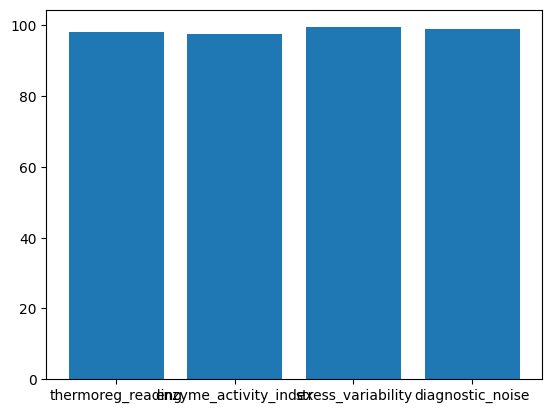

In [6]:
# Code cell
# For this data, I believe the target proportion should be the sum of the percentage of the upper and lower outliers.
# Due to this clause, we do not need to define a target proportion for features where the IQR definiton shows outliers to be insignifigant
# (dual_lobe_signal and activity_score)
# I would also like to add that though health_outcomes has significantly more data (+~200) when compared to the rest of the classes, that
# the difference will not have a significant impact on the result, as the mean of the column is  essentially a 50/50 split between 1 and 0
# (A mean of 0.49980)

def calculateTargetProps(d, column, features, targetPropValue):
    newFeatures = features
    newValues = targetPropValue

    Q1 = d[column].quantile(0.25)
    Q3 = d[column].quantile(0.75)
    IQR = Q3-Q1

    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR

    outlier_lower_list = [x for x in d[column] if (x < lower_range)]
    outlier_upper_list = [x for x in d[column] if (x > upper_range)]
    targetProportion =  100.000 - ( ( ( len(outlier_lower_list)/ d[column].count() ) *100) + ( ( len(outlier_upper_list)/ d[column].count() ) *100) ).astype(float).round(3)

    print("Target proportion for %s: %s" % (column, targetProportion.astype(str)))
    newFeatures.append(column)
    newValues.append(targetProportion)
    return newFeatures, newValues

targetProportionFeatures = []
targetProportionValue = []

targetProportionFeatures, targetProportionValue = calculateTargetProps(cleanData, 'thermoreg_reading', targetProportionFeatures, targetProportionValue)
#print(targetProportionValue)
targetProportionFeatures, targetProportionValue = calculateTargetProps(cleanData, 'enzyme_activity_index', targetProportionFeatures, targetProportionValue)
targetProportionFeatures, targetProportionValue = calculateTargetProps(cleanData, 'stress_variability', targetProportionFeatures, targetProportionValue)
targetProportionFeatures, targetProportionValue = calculateTargetProps(cleanData, 'diagnostic_noise', targetProportionFeatures, targetProportionValue)


plt.bar(targetProportionFeatures, targetProportionValue)
plt.show()


7. **Save the clean data**

	- Keep the core features plus `health_outcome`.
	- Ensure correct dtypes (numeric/ordinal/binary).
	- Save as `alien_pet_health_cleaned.csv`.

In [7]:
# Code cell
cleanData.to_csv('alien_pet_health_cleaned.csv', index=False) 

# References


# Resources


If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation 


Resources that I used:
https://www.w3schools.com/python
https://www.geeksforgeeks.org/pandas/pandas-tutorial/
https://math.stackexchange.com/questions/966331/why-john-tukey-set-1-5-iqr-to-detect-outliers-instead-of-1-or-2
https://medium.com/data-and-beyond/outlier-detection-in-r-tukey-method-or-why-you-need-box-and-whiskers-3c35d9ad8fb3
Google AI Mode (Gemini 2.5) https://share.google/aimode/0TDPl1H5zPnlr0KcG